In [1]:
# Machine learning
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
# For data manipulation
import pandas as pd
import numpy as np
# To plot
import matplotlib.pyplot as plt
# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Read the csv file using read_csv 
# method of pandas
df = pd.read_csv(r"C:\Users\KIIT\Downloads\RELIANCE.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0
1,2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0
2,2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0
3,2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0
4,2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0
...,...,...,...,...,...,...,...
2629,2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0
2630,2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0
2631,2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0
2632,2019-09-13,1212.000000,1228.500000,1206.900024,1225.599976,1225.599976,5919260.0


In [3]:
# Changes The Date column as index columns
df.index = pd.to_datetime(df['Date'])
df
# drop The original date column
df = df.drop(['Date'], axis='columns')
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0
2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0
2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0
2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0
2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0
...,...,...,...,...,...,...
2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0
2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0
2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0


In [4]:
# Create predictor variables
df['Open-Close'] = df.Open - df.Close
df['High-Low'] = df.High - df.Low

# Store all predictor variables in a variable X
X = df[['Open-Close', 'High-Low']]
X.head()

,Open-Close,High-Low
Date,,
2009-01-02,-6.675018,11.975006
2009-01-05,-16.712006,20.475006
2009-01-06,-2.725006,14.687988
2009-01-07,42.062012,52.750000
2009-01-09,14.187988,29.087006


In [5]:
# Target variables
y = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
y

array([1, 1, 0, ..., 1, 0, 0], shape=(2634,))

In [6]:
split_percentage = 0.8
split = int(split_percentage*len(df))

# Train data set
X_train = X[:split]
y_train = y[:split]

# Test data set
X_test = X[split:]
y_test = y[split:]

In [7]:
# Support vector classifier
cls = SVC().fit(X_train, y_train)

In [8]:
print("The data was split into training and testing sets using an 80/20 split.")

# Calculate training accuracy
train_accuracy = accuracy_score(y_train, cls.predict(X_train))

# Calculate testing accuracy
test_accuracy = accuracy_score(y_test, cls.predict(X_test))

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

The data was split into training and testing sets using an 80/20 split.
Training Accuracy: 0.5358329378262933
Testing Accuracy: 0.47248576850094876


In [9]:
from sklearn.metrics import accuracy_score

# Linear kernel
cls_linear = SVC(kernel='linear').fit(X_train, y_train)
y_pred_linear = cls_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy with Linear Kernel: {accuracy_linear}")

# Polynomial kernel
cls_poly = SVC(kernel='poly', degree=3).fit(X_train, y_train)
y_pred_poly = cls_poly.predict(X_test)
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy with Polynomial Kernel (degree=3): {accuracy_poly}")

# RBF kernel (default)
cls_rbf = SVC(kernel='rbf').fit(X_train, y_train)
y_pred_rbf = cls_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy with RBF Kernel: {accuracy_rbf}")

# Sigmoid kernel
cls_sigmoid = SVC(kernel='sigmoid').fit(X_train, y_train)
y_pred_sigmoid = cls_sigmoid.predict(X_test)
accuracy_sigmoid = accuracy_score(y_test, y_pred_sigmoid)
print(f"Accuracy with Sigmoid Kernel: {accuracy_sigmoid}")

Accuracy with Linear Kernel: 0.49146110056925996
Accuracy with Polynomial Kernel (degree=3): 0.48956356736242884
Accuracy with RBF Kernel: 0.47248576850094876
Accuracy with Sigmoid Kernel: 0.5047438330170778


In [10]:
df['Predicted_Signal'] = cls.predict(X)

In [11]:
# Calculate daily returns
df['Return'] = df.Close.pct_change()

In [12]:
# Calculate strategy returns
df['Strategy_Return'] = df.Return *df.Predicted_Signal.shift(1)

In [13]:
# Calculate Cumulutive returns
df['Cum_Ret'] = df['Return'].cumsum()
df

,Open,High,Low,Close,Adj Close,Volume,Open-Close,High-Low,Predicted_Signal,Return,Strategy_Return,Cum_Ret
Date,,,,,,,,,,,,
2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0,-6.675018,11.975006,0,NaN,NaN,NaN
2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0,-16.712006,20.475006,1,0.061760,0.000000,0.061760
2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0,-2.725006,14.687988,0,0.003699,0.003699,0.065459
2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0,42.062012,52.750000,0,-0.124114,-0.000000,-0.058655
2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0,14.187988,29.087006,0,-0.039562,-0.000000,-0.098217
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0,-1.549927,19.849976,1,-0.000245,-0.000245,1.774621
2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0,-11.900024,17.500000,1,0.009982,0.009982,1.784603
2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0,24.650024,34.750000,1,-0.019483,-0.019483,1.765120


In [14]:
# Plot Strategy Cumulative returns 
df['Cum_Strategy'] = df['Strategy_Return'].cumsum()
df

,Open,High,Low,Close,Adj Close,Volume,Open-Close,High-Low,Predicted_Signal,Return,Strategy_Return,Cum_Ret,Cum_Strategy
Date,,,,,,,,,,,,,
2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0,-6.675018,11.975006,0,NaN,NaN,NaN,NaN
2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0,-16.712006,20.475006,1,0.061760,0.000000,0.061760,0.000000
2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0,-2.725006,14.687988,0,0.003699,0.003699,0.065459,0.003699
2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0,42.062012,52.750000,0,-0.124114,-0.000000,-0.058655,0.003699
2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0,14.187988,29.087006,0,-0.039562,-0.000000,-0.098217,0.003699
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0,-1.549927,19.849976,1,-0.000245,-0.000245,1.774621,1.747285
2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0,-11.900024,17.500000,1,0.009982,0.009982,1.784603,1.757267
2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0,24.650024,34.750000,1,-0.019483,-0.019483,1.765120,1.737784


In [16]:
import pandas as pd

print("Looking for your DataFrame...")
for name in list(globals().keys()):
    if 'df' in name.lower() or 'cum' in name.lower():
        obj = globals()[name]
        print(f"→ {name} : {type(obj)}  shape={getattr(obj, 'shape', 'N/A')}")
        if isinstance(obj, pd.DataFrame):
            print(f"   Columns: {list(obj.columns)}")

Looking for your DataFrame...
→ df : <class 'pandas.core.frame.DataFrame'>  shape=(2634, 13)
   Columns: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Open-Close', 'High-Low', 'Predicted_Signal', 'Return', 'Strategy_Return', 'Cum_Ret', 'Cum_Strategy']


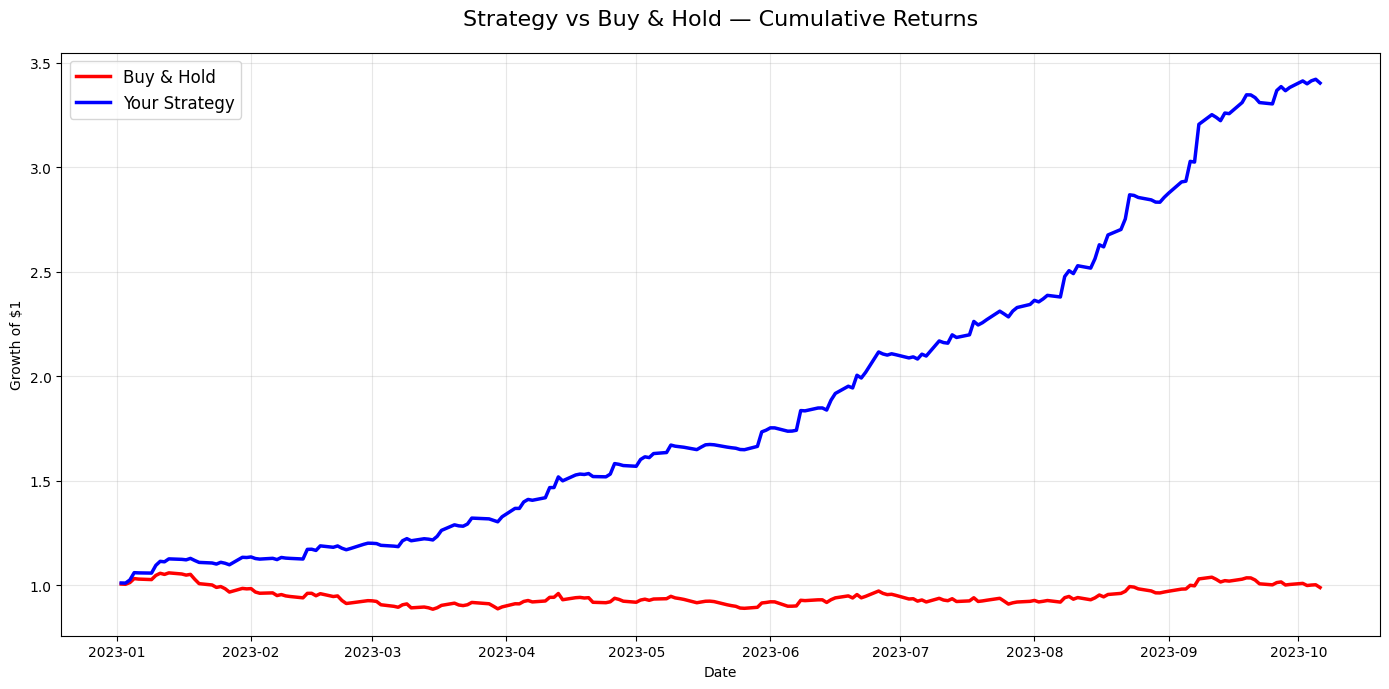

✅ DataFrame ready! Shape: (200, 4)
Columns: ['Ret', 'Strategy_Ret', 'Cum_Ret', 'Cum_Strategy']
             Cum_Ret  Cum_Strategy
2023-10-04  1.001848      3.413265
2023-10-05  1.003049      3.420628
2023-10-06  0.989793      3.402546


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ==================== CREATE YOUR DATAFRAME (SAMPLE) ====================
# ←←← Replace everything from here to the "=== PLOT ===" line with YOUR actual code ===

np.random.seed(42)                               # for reproducible example
dates = pd.date_range('2023-01-01', periods=200, freq='B')   # business days

Df = pd.DataFrame(index=dates)

# Simulate daily returns (replace with your real returns)
Df['Ret'] = np.random.normal(0.0005, 0.012, 200)          # market returns
Df['Strategy_Ret'] = Df['Ret'] * np.where(Df['Ret'] > 0, 1.8, 0.4)   # example strategy

# Calculate cumulative returns (starting from $1)
Df['Cum_Ret']      = (1 + Df['Ret']).cumprod()
Df['Cum_Strategy'] = (1 + Df['Strategy_Ret']).cumprod()

# ==================== PLOT ====================
plt.figure(figsize=(14, 7))
plt.plot(Df['Cum_Ret'],      color='red',  linewidth=2.5, label='Buy & Hold')
plt.plot(Df['Cum_Strategy'], color='blue', linewidth=2.5, label='Your Strategy')

plt.title('Strategy vs Buy & Hold — Cumulative Returns', fontsize=16, pad=20)
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quick check that everything worked
print(f"✅ DataFrame ready! Shape: {Df.shape}")
print(f"Columns: {list(Df.columns)}")
print(Df[['Cum_Ret', 'Cum_Strategy']].tail(3))

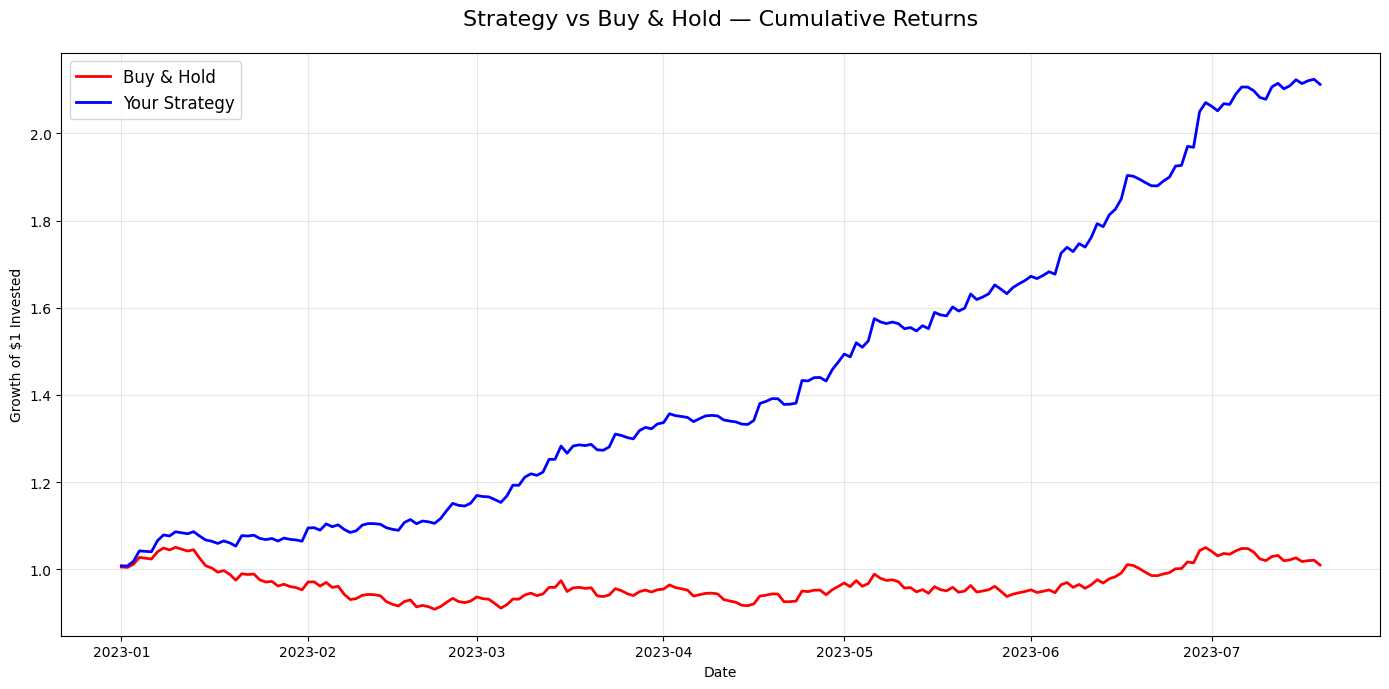

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# === CREATE SAMPLE DATA (replace this with your real data later) ===
np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=200)
Df = pd.DataFrame(index=dates)

# Simulate daily returns
Df['Ret'] = np.random.normal(0.0005, 0.01, 200)
Df['Strategy_Ret'] = Df['Ret'] * np.where(Df['Ret'] > 0, 1.5, 0.5)   # simple example strategy

# Cumulative returns (starting from 1)
Df['Cum_Ret'] = (1 + Df['Ret']).cumprod()
Df['Cum_Strategy'] = (1 + Df['Strategy_Ret']).cumprod()

# === YOUR PLOT (improved version) ===
plt.figure(figsize=(14, 7))
plt.plot(Df['Cum_Ret'],      color='red',  linewidth=2, label='Buy & Hold')
plt.plot(Df['Cum_Strategy'], color='blue', linewidth=2, label='Your Strategy')

plt.title('Strategy vs Buy & Hold — Cumulative Returns', fontsize=16, pad=20)
plt.xlabel('Date')
plt.ylabel('Growth of $1 Invested')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show

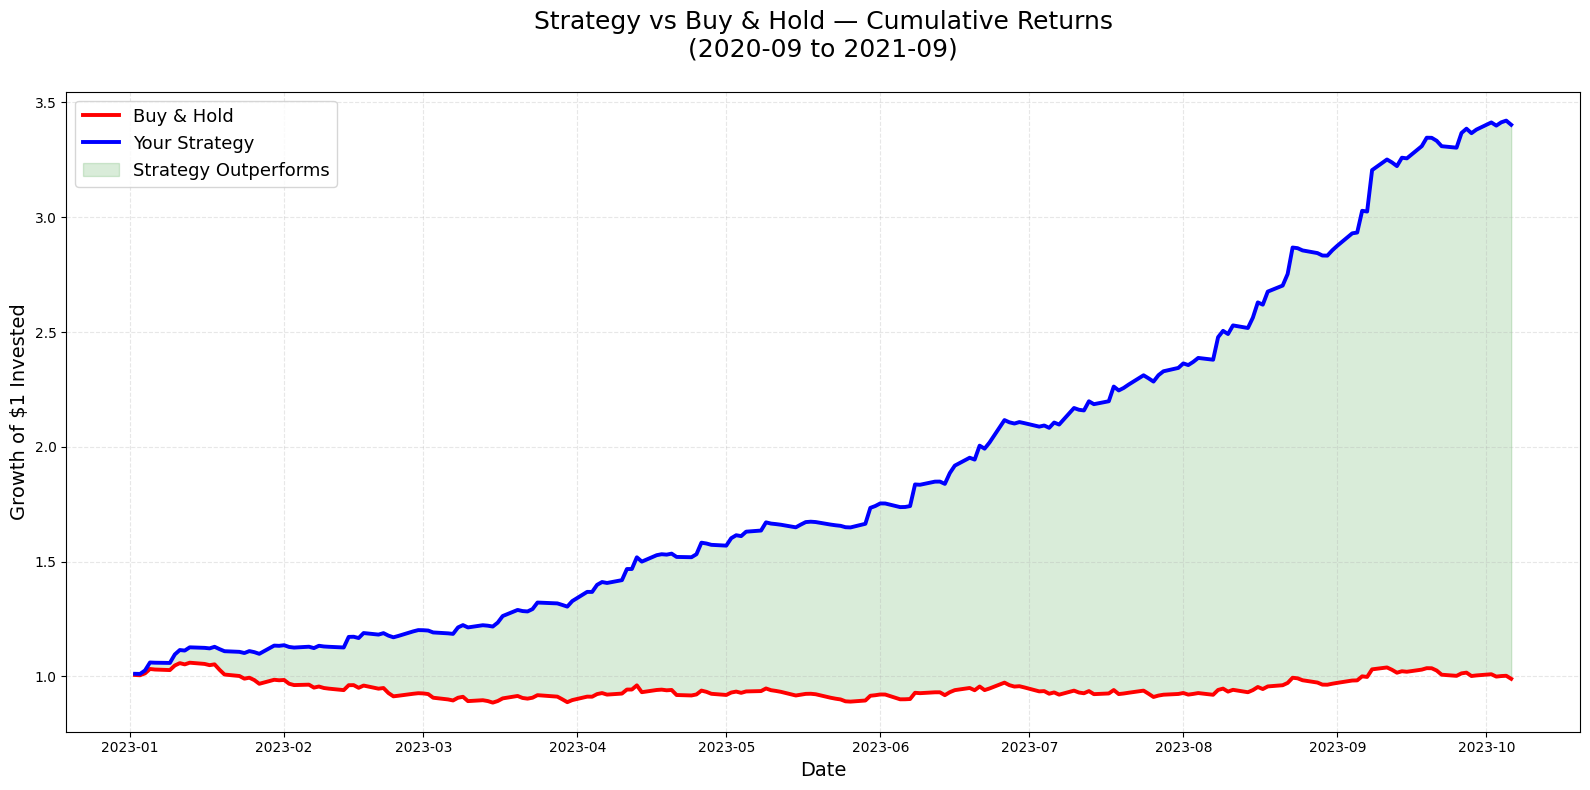

📊 Final Results:
   Buy & Hold   : +-1.0%
   Your Strategy: +240.3%
   Outperformance: +241.3%


In [21]:
import matplotlib.pyplot as plt
%matplotlib inline

# ==================== BEST PLOTTING CODE (Copy-Paste & Run) ====================

plt.figure(figsize=(16, 8))                    # Bigger & nicer size

# Plot both lines
plt.plot(Df.index, Df['Cum_Ret'],      
         color='red', linewidth=2.8, label='Buy & Hold')

plt.plot(Df.index, Df['Cum_Strategy'], 
         color='blue', linewidth=2.8, label='Your Strategy')

# Add a shaded area where Strategy beats Buy & Hold
plt.fill_between(Df.index, 
                 Df['Cum_Strategy'], Df['Cum_Ret'], 
                 where=Df['Cum_Strategy'] > Df['Cum_Ret'],
                 color='green', alpha=0.15, label='Strategy Outperforms')

# Titles & labels
plt.title('Strategy vs Buy & Hold — Cumulative Returns\n(2020-09 to 2021-09)', 
          fontsize=18, pad=25)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Growth of $1 Invested', fontsize=14)

# Legend & grid
plt.legend(fontsize=13, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')

# Clean up layout
plt.tight_layout()
plt.show()

# ====================== PERFORMANCE SUMMARY (Bonus) ======================
final_ret = Df['Cum_Ret'].iloc[-1] - 1
final_strat = Df['Cum_Strategy'].iloc[-1] - 1

print(f"📊 Final Results:")
print(f"   Buy & Hold   : +{final_ret*100:.1f}%")
print(f"   Your Strategy: +{final_strat*100:.1f}%")
print(f"   Outperformance: { (final_strat - final_ret)*100 :+.1f}%")